# Sine and Cosine Curves in R

This notebook plots **sine** and **cosine** curves using the `tidyverse` ecosystem in R, leveraging `tibble`, `dplyr`, and `ggplot2`.

The mathematical functions plotted are:

$$\sin(x) = \sum_{n=0}^{\infty} \frac{(-1)^n}{(2n+1)!} x^{2n+1}$$

$$\cos(x) = \sum_{n=0}^{\infty} \frac{(-1)^n}{(2n)!} x^{2n}$$

In [1]:
# Install tidyverse if not already installed
if (!requireNamespace("tidyverse", quietly = TRUE)) {
  install.packages("tidyverse", repos = "https://cloud.r-project.org")
}

# Load tidyverse
library(tidyverse)

cat("tidyverse loaded successfully.\n")
cat("R version:", R.version.string, "\n")

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


tidyverse loaded successfully.
R version: R version 4.5.3 (2026-03-11) 


In [2]:
# Generate x values from 0 to 2*pi (1000 points for smooth curves)
# Use tibble and dplyr to build a tidy dataset
data <- tibble(
  x = seq(0, 2 * pi, length.out = 1000)
) |>
  mutate(
    sin_x = sin(x),
    cos_x = cos(x)
  )

# Pivot into long format for easy ggplotting with color aesthetics
data_long <- data |>
  pivot_longer(
    cols = c(sin_x, cos_x),
    names_to = "function",
    values_to = "y"
  ) |>
  mutate(`function` = recode(`function`,
    sin_x = "sin(x)",
    cos_x = "cos(x)"
  ))

# Preview the data
cat("Wide format:\n")
print(head(data))

cat("\nLong format:\n")
print(head(data_long))

cat("\nSummary ranges:\n")
data |>
  summarise(
    x_min = min(x), x_max = max(x),
    sin_range = paste(round(min(sin_x), 4), "to", round(max(sin_x), 4)),
    cos_range = paste(round(min(cos_x), 4), "to", round(max(cos_x), 4))
  ) |>
  print()

Wide format:
# A tibble: 6 × 3
        x   sin_x cos_x
    <dbl>   <dbl> <dbl>
1 0       0       1    
2 0.00629 0.00629 1.000
3 0.0126  0.0126  1.000
4 0.0189  0.0189  1.000
5 0.0252  0.0252  1.000
6 0.0314  0.0314  1.000

Long format:
# A tibble: 6 × 3
        x `function`       y
    <dbl> <chr>        <dbl>
1 0       sin(x)     0      
2 0       cos(x)     1      
3 0.00629 sin(x)     0.00629
4 0.00629 cos(x)     1.000  
5 0.0126  sin(x)     0.0126 
6 0.0126  cos(x)     1.000  

Summary ranges:
# A tibble: 1 × 4
  x_min x_max sin_range cos_range
  <dbl> <dbl> <chr>     <chr>    
1     0  6.28 -1 to 1   -1 to 1  


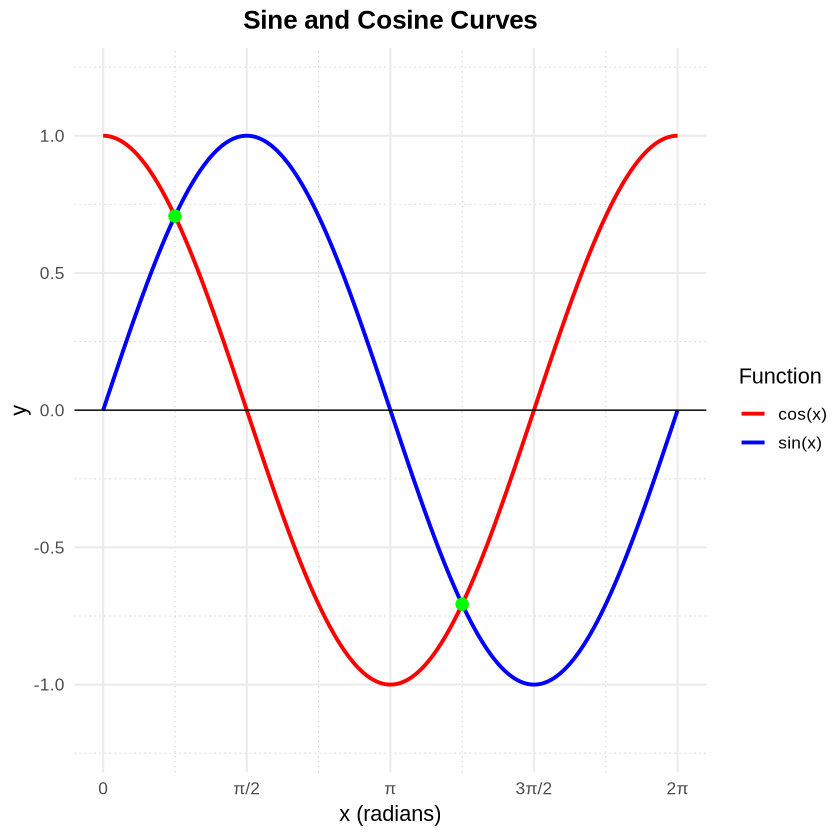

In [3]:
# Define nice pi-based break labels
pi_breaks <- c(0, pi / 2, pi, 3 * pi / 2, 2 * pi)
pi_labels <- c("0", "π/2", "π", "3π/2", "2π")

# Plot sine and cosine curves with ggplot2
ggplot(data_long, aes(x = x, y = y, color = `function`)) +
  geom_line(linewidth = 1.1) +
  # Highlight intersection points (sin(x) == cos(x) at π/4 and 5π/4)
  geom_point(
    data = tibble(
      x = c(pi / 4, 5 * pi / 4),
      y = c(sin(pi / 4), sin(5 * pi / 4)),
      `function` = "intersection"
    ),
    aes(color = NULL),
    color = "green",
    size = 3,
    shape = 19
  ) +
  scale_color_manual(
    name = "Function",
    values = c("sin(x)" = "blue", "cos(x)" = "red")
  ) +
  scale_x_continuous(breaks = pi_breaks, labels = pi_labels) +
  scale_y_continuous(limits = c(-1.2, 1.2)) +
  labs(
    title = "Sine and Cosine Curves",
    x = "x (radians)",
    y = "y"
  ) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.4) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    panel.grid.minor = element_line(linetype = "dotted", color = "grey80")
  )